#### Supp. Fig 3e

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os 
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import math
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})



In [3]:
save_dir = "f2"
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

In [6]:
# load adata
adata_vis = sc.read_h5ad(f"/Users/jk/Documents/Lab2/visium/python_analysis/local_401/h5ad/adata_vis_assigned_cell_types_Banovich_Kropski_2020.h5ad")

In [7]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_vis)
# Logarithmize the data
sc.pp.log1p(adata_vis)

In [8]:
adata_vis.var_names

Index(['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15',
       'AGRN', 'RNF223', 'C1orf159',
       ...
       'MT-CO1', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=16959)

In [9]:
cell_type_order = [
    'AT1', 
    'AT2', 'Transitional AT2', "Basal", "KRT5-/KRT17+",
    'MUC5B+', "MUC5AC+ High", "SCGB3A2+", "SCGB3A2+ SCGB1A1+",
    'Ciliated', 'Differentiating Ciliated', "Proliferating Epithelial Cells",

    "T Cells", "NK Cells", "Macrophages", "Monocytes", "cDCs", "pDCs",
    "Plasma Cells", "B Cells",# "Mast Cells", 
    "Proliferating T Cells", "Proliferating Macrophages",

    "Endothelial Cells", "Lymphatic Endothelial Cells",

    "Smooth Muscle Cells", "Mesothelial Cells", "Myofibroblasts", "HAS1 High Fibroblasts",
    "Fibroblasts", "PLIN2+ Fibroblasts"
]

In [10]:
# df  = adata_vis.obs[ct_order]
df = adata_vis.obs[cell_type_order]

In [11]:
df_norm = df.div(df.sum(axis=1), axis=0) 

In [12]:
df_norm_cat = pd.concat([df_norm, adata_vis.obs[['library_id','cell_type_assigned']]], axis=1)

In [13]:
df_norm_cat

,AT1,AT2,Transitional AT2,Basal,KRT5-/KRT17+,MUC5B+,MUC5AC+ High,SCGB3A2+,SCGB3A2+ SCGB1A1+,Ciliated,Differentiating Ciliated,Proliferating Epithelial Cells,T Cells,NK Cells,Macrophages,Monocytes,cDCs,pDCs,Plasma Cells,B Cells,Proliferating T Cells,Proliferating Macrophages,Endothelial Cells,Lymphatic Endothelial Cells,Smooth Muscle Cells,Mesothelial Cells,Myofibroblasts,HAS1 High Fibroblasts,Fibroblasts,PLIN2+ Fibroblasts,library_id,cell_type_assigned
AACACGTGCATCGCAC-1-18_57617_A1,0.000026,0.000012,0.000009,0.004665,0.000069,0.000029,0.003470,0.000036,0.000083,0.004840,0.000163,0.000135,0.001233,0.001150,0.000259,0.000345,0.001593,0.079751,0.179013,0.555538,0.006055,0.000352,0.001818,0.002188,0.014905,0.000279,0.029373,0.000078,0.104530,0.008003,18_57617_A1,B Cells
AACACTTGGCAAGGAA-1-18_57617_A1,0.108209,0.032824,0.005283,0.002462,0.002605,0.006661,0.001109,0.006373,0.026199,0.040573,0.023480,0.001431,0.008660,0.005568,0.041179,0.019274,0.009821,0.003760,0.001595,0.007116,0.019060,0.057278,0.299330,0.011714,0.109060,0.004229,0.088104,0.000774,0.054423,0.001845,18_57617_A1,Endothelial Cells
AACAGGATTCATAGTT-1-18_57617_A1,0.006594,0.011538,0.001780,0.000790,0.002437,0.000226,0.000619,0.000306,0.000370,0.001367,0.000397,0.000429,0.009662,0.003966,0.005604,0.003516,0.064488,0.009380,0.000357,0.001705,0.024596,0.007317,0.761460,0.008387,0.036491,0.001143,0.031974,0.000304,0.002536,0.000259,18_57617_A1,Endothelial Cells
AACAGGTTCACCGAAG-1-18_57617_A1,0.005105,0.010739,0.000193,0.002531,0.000246,0.000040,0.000053,0.000202,0.000265,0.028340,0.000272,0.000510,0.005883,0.005866,0.005306,0.010019,0.001212,0.002770,0.001012,0.036808,0.128574,0.000474,0.708556,0.008767,0.014793,0.001238,0.014478,0.000428,0.004899,0.000423,18_57617_A1,Endothelial Cells
AACAGTCAGGCTCCGC-1-18_57617_A1,0.003859,0.002656,0.002180,0.088780,0.297039,0.000144,0.000070,0.061278,0.001048,0.000646,0.000441,0.000275,0.004507,0.003754,0.372034,0.012172,0.003542,0.001099,0.000057,0.001698,0.006725,0.014176,0.001793,0.000677,0.000410,0.000163,0.082884,0.032775,0.002491,0.000627,18_57617_A1,Macrophages
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTCATTGGTCCAAG-1-22_16220_B1,0.090554,0.243505,0.017195,0.000212,0.000672,0.000299,0.000161,0.000809,0.000393,0.000109,0.000043,0.000485,0.116983,0.011864,0.026833,0.018941,0.032278,0.006288,0.001157,0.001479,0.028913,0.011300,0.242063,0.003347,0.009794,0.000163,0.128937,0.000295,0.004047,0.000881,22_16220_B1,AT2
TGTTGCGTCCAAGATT-1-22_16220_B1,0.075941,0.014331,0.221443,0.000871,0.238904,0.000302,0.000338,0.000887,0.000556,0.000275,0.000143,0.000752,0.014119,0.003203,0.052835,0.004842,0.063379,0.004394,0.026804,0.006552,0.015255,0.007527,0.068954,0.004872,0.002133,0.001616,0.128627,0.020368,0.006142,0.013635,22_16220_B1,KRT5-/KRT17+
TGTTGGAAGCTCGGTA-1-22_16220_B1,0.029071,0.173176,0.018738,0.002971,0.035890,0.000187,0.000651,0.001874,0.000992,0.002401,0.000474,0.002831,0.012929,0.014519,0.186316,0.077852,0.077767,0.004522,0.067793,0.017105,0.114870,0.006205,0.054167,0.001633,0.000794,0.000337,0.084165,0.003239,0.002896,0.003634,22_16220_B1,Macrophages
TGTTGGATGGACTTCT-1-22_16220_B1,0.045896,0.554157,0.022010,0.034960,0.000851,0.000595,0.003996,0.008223,0.001299,0.004130,0.001960,0.006366,0.012068,0.011380,0.097119,0.003965,0.019612,0.024369,0.013820,0.005085,0.025270,0.008080,0.042468,0.006597,0.001140,0.003051,0.034455,0.001003,0.003986,0.002087,22_16220_B1,AT2


In [14]:

# Load the data

# Set threshold
threshold = 0.5  

# Get unique cell types from the 'cell_type_proportion' column
cell_types = df_norm_cat['cell_type_assigned'].unique()

# Initialize a set to store all passing indices
passing_indices = set()

# Loop over each cell type and collect indices that pass the threshold
for ct in cell_types:
    if ct in df_norm_cat.columns:
        idx = df_norm_cat[df_norm_cat[cell_type_order] > threshold].index
        passing_indices.update(idx)
    else:
        print(f"Skipping '{ct}' – not found as a column.")

# Final list of unique indices
filtered_indices = sorted(passing_indices)

# Subset anndata
adata_filtered = adata_vis[filtered_indices].copy()

# Order or restrict cell types shown on dotplot
adata_filtered = adata_filtered[adata_filtered.obs['cell_type_assigned'].isin(cell_type_order)]



Skipping 'Mast Cells' – not found as a column.


In [16]:
adata_filtered

View of AnnData object with n_obs × n_vars = 20724 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT1', 'AT2', 'B Cells', 'Basal', 'Ciliated', 'Differentiating Ciliated', 'Endothelial Cells', 'Fib

In [17]:
markers = [
    # Epithelial
    "EPCAM", 
    "AGER", 'SFTPC', "ABCA3", 
    "KRT5", #"KRT17",
    "MUC5B",
    "SCGB3A1","SCGB3A2", 
    "FOXJ1",

    # immune
    "PTPRC",
    "CD3E", 
    "LYZ",# "MARCO", 
    #"JCHAIN",

    # Endo
    "PECAM1",

    # Mesenchymal
    "ACTA2", "MYH11",
    "LUM"

]

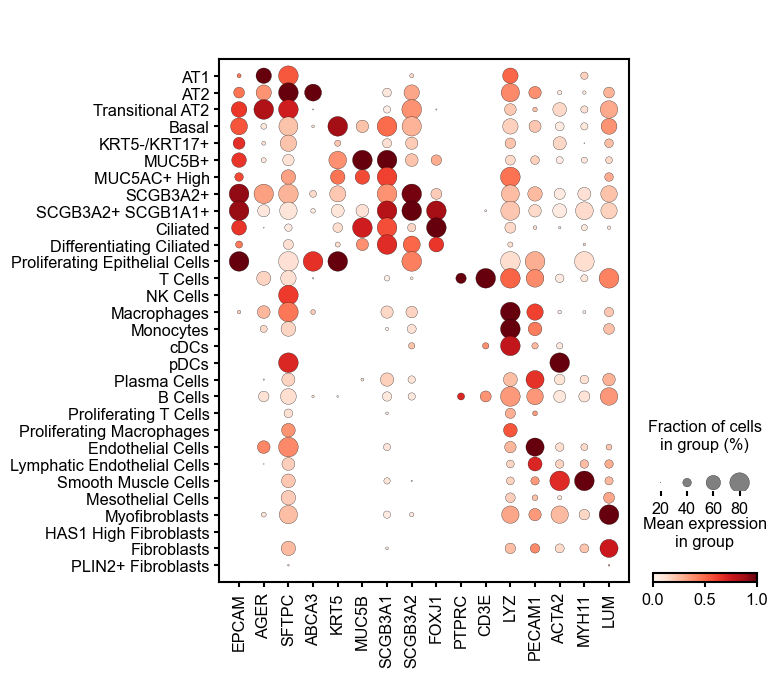

In [18]:
fig, ax = plt.subplots(1,1, figsize = (8,7))
sc.pl.dotplot(adata_filtered, markers, groupby="cell_type_assigned", dendrogram=False,
              categories_order= cell_type_order,
              #var_group_labels=["Epithelial", "Immune","Endothelial","Mesenchymal"],
              #var_group_positions=[(0,9),(10,14),(15,15),(16,18)],



              standard_scale='var', ax = ax,
              dot_min=0.2, dot_max = 0.8, show = False)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"dotplot_50p_fitered.pdf"), bbox_inches = "tight")
plt.show()